# Skenario B - Custom CNN dengan Data Augmentation
**Proyek Skripsi:** Klasifikasi Jenis Obat Tablet Menggunakan Convolutional Neural Network (CNN)

## Tujuan Notebook Ini:
1. Memuat dataset dari `baseline_dataset`.
2. Menerapkan teknik **Data Augmentation** secara *on-the-fly* (agresif) menggunakan `ImageDataGenerator` pada data latih (rotasi, *zoom*, translasi, dan *flip*).
3. Membangun arsitektur Custom CNN yang **sama persis** dengan Skenario A untuk menjaga keadilan perbandingan (*fair comparison*).
4. Melatih model dan mengevaluasi peningkatannya dibandingkan Skenario A.
5. Menyimpan artefak model dan grafik untuk pembahasan BAB IV Skripsi.

In [1]:
# Import library yang dibutuhkan
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

# Hubungkan Google Drive
drive.mount('/content/drive')

print("✅ Library berhasil diimpor dan Google Drive terhubung.")

Mounted at /content/drive
✅ Library berhasil diimpor dan Google Drive terhubung.


## 1. Konfigurasi Parameter & Augmentasi Data (Crucial Step)
Di sinilah letak perbedaan utama dengan Skenario A. Kita menginstruksikan `ImageDataGenerator` pada `train_datagen` untuk memanipulasi citra secara acak di setiap iterasi (*epoch*).

*Penting: Data Validasi dan Data Uji **TIDAK BOLEH** diaugmentasi, hanya dinormalisasi pikselnya agar evaluasi tetap murni dan valid secara akademis.*

In [2]:
# ==========================================
# KONFIGURASI DIREKTORI & HYPERPARAMETER
# ==========================================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB'
BASELINE_DIR = os.path.join(BASE_DIR, 'data', 'baseline_dataset')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs', 'scenario_b')

# Buat folder output khusus Skenario B
os.makedirs(OUTPUTS_DIR, exist_ok=True)

TARGET_CLASSES = [
    "cataflam_50_mg", "cetirizin_10_mg", "pantoprazol_sandoz_40_mg",
    "c_vitamin_teva_500_mg", "aspirin_ultra_500_mg",
    "algoflex_forte_dolo_400_mg", "merckformin_xr_1000_mg"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50

def create_augmented_data_generators():
    """
    Membuat data generator dengan tambahan teknik Data Augmentation untuk data latih.
    """
    # 1. Generator Data Latih (Dengan Augmentasi Agresif)
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=30,           # Memutar gambar hingga 30 derajat
        width_shift_range=0.1,       # Menggeser horizontal 10%
        height_shift_range=0.1,      # Menggeser vertikal 10%
        zoom_range=0.2,              # Memperbesar/memperkecil 20%
        horizontal_flip=True,        # Membalik gambar secara horizontal
        fill_mode='nearest'          # Mengisi piksel kosong akibat rotasi/shift
    )

    # 2. Generator Data Validasi & Test (MURNI, TANPA AUGMENTASI)
    val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

    print("Memuat Data Latih (Train) dengan Augmentasi...")
    train_gen = train_datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=True
    )

    print("Memuat Data Validasi (Validation)...")
    val_gen = val_test_datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'valid'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=False
    )

    print("Memuat Data Uji (Test)...")
    test_gen = val_test_datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'test'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

# Eksekusi pembuatan generator
train_generator, val_generator, test_generator = create_augmented_data_generators()

Memuat Data Latih (Train) dengan Augmentasi...
Found 196 images belonging to 7 classes.
Memuat Data Validasi (Validation)...
Found 42 images belonging to 7 classes.
Memuat Data Uji (Test)...
Found 42 images belonging to 7 classes.


## 2. Perancangan Arsitektur Custom CNN (Identik dengan Skenario A)
Untuk mengisolasi variabel eksperimen, arsitektur yang digunakan harus 100% sama dengan Skenario A. Jika kita merubah arsitektur, kita tidak akan bisa membuktikan apakah peningkatan akurasi disebabkan oleh augmentasi atau karena perubahan model.

In [3]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=7):
    """
    Arsitektur Custom CNN yang konsisten dengan Skenario A.
    """
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Inisialisasi model
model_b = build_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=len(TARGET_CLASSES))
model_b.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Proses Training Skenario B
Sama halnya dengan Skenario A, kita menggunakan *ModelCheckpoint* dan *EarlyStopping*. Waktu pelatihan mungkin sedikit lebih lama dari Skenario A karena CPU harus melakukan komputasi transformasi augmentasi gambar pada setiap iterasi (*batch*).

In [4]:
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'scenario_b.h5')

def train_model(model, train_gen, val_gen):
    """
    Mengeksekusi proses pelatihan (training) model.
    """
    checkpoint = ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    print("\n🚀 Memulai Proses Pelatihan Skenario B (Augmentasi)...")
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

    return history

# Eksekusi Training
history_b = train_model(model_b, train_generator, val_generator)


🚀 Memulai Proses Pelatihan Skenario B (Augmentasi)...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1378 - loss: 2.8718
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_b.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_b.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.1276 - loss: 2.4389 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.1779 - loss: 1.9447
Epoch 2: val_accuracy did not improve from 0.14286
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 0.1582 - loss: 1.9548 - val_accuracy: 0.1429 - val_loss: 1.9474
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.1383 - loss: 1.9397
Epoch 3: val_accuracy did not improve from 0.14286
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.1531 - loss: 1.9448 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.1105 - loss: 1.9462
Epoch 4: val_accuracy did not improve from 0.14286
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.1276 - loss: 1.9462 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 5/5

## 4. Evaluasi & Visualisasi Hasil Training (Learning Curves)
Secara teoretis, Anda akan melihat garis `Validation Loss` dan `Validation Accuracy` bergerak lebih stabil dan lebih merapat (*converge*) dengan garis `Training` dibandingkan dengan kurva pada Skenario A.

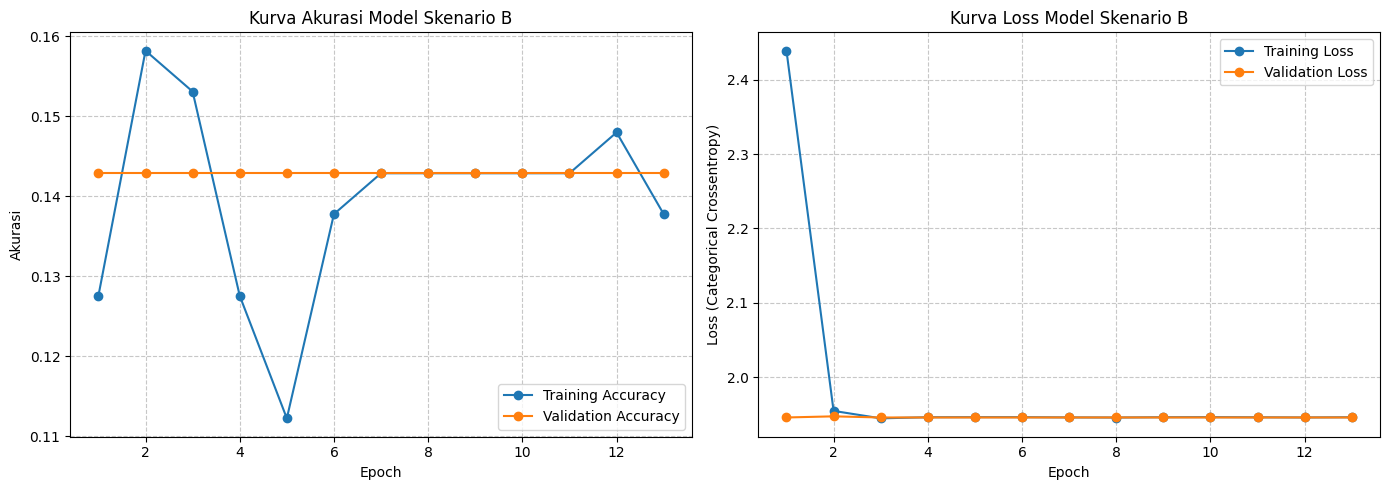

In [5]:
def plot_learning_curves(history, save_dir):
    """
    Menghasilkan grafik perbandingan loss dan akurasi.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Kurva Akurasi Model Skenario B')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Kurva Loss Model Skenario B')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'scenario_b_learning_curves.png'), dpi=300)
    plt.show()

plot_learning_curves(history_b, OUTPUTS_DIR)

## 5. Pengujian Kinerja Akhir (Testing)
Validasi model `scenario_b.h5` terhadap data uji murni yang sama. Kita akan membuktikan apakah kemampuan model dalam mengenali fitur (*imprint*, warna, bentuk) menjadi lebih tangguh (*robust*) berkat augmentasi.


🔍 Memuat Model Terbaik dan Mengevaluasi Data Uji...


✅ Akurasi Uji Global (Test Accuracy): 14.29%
✅ Nilai Loss Uji (Test Loss): 1.9459

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step

--- CLASSIFICATION REPORT ---
                            precision    recall  f1-score   support

            cataflam_50_mg       0.00      0.00      0.00         6
           cetirizin_10_mg       0.14      1.00      0.25         6
  pantoprazol_sandoz_40_mg       0.00      0.00      0.00         6
     c_vitamin_teva_500_mg       0.00      0.00      0.00         6
      aspirin_ultra_500_mg       0.00      0.00      0.00         6
algoflex_forte_dolo_400_mg       0.00      0.00      0.00         6
    merckformin_xr_1000_mg       0.00      0.00      0.00         6

                  accuracy                           0.14        42
                 macro avg       0.02      0.14      0.04        42
              weighted avg       0.02      0.14      0.04        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


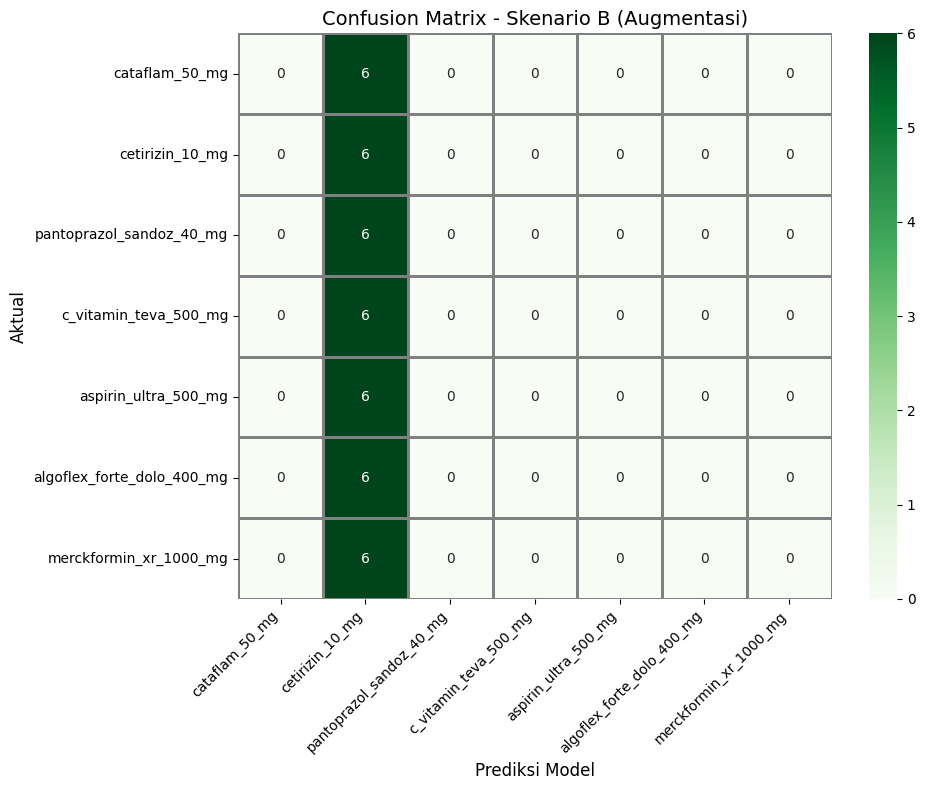

In [6]:
def evaluate_model_on_test(model_path, test_gen, classes, save_dir):
    """
    Mengevaluasi Skenario B pada Test Set dan menyimpan artefak skripsi.
    """
    print("\n🔍 Memuat Model Terbaik dan Mengevaluasi Data Uji...")
    best_model = tf.keras.models.load_model(model_path)

    test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
    print(f"✅ Akurasi Uji Global (Test Accuracy): {test_acc * 100:.2f}%")
    print(f"✅ Nilai Loss Uji (Test Loss): {test_loss:.4f}\n")

    test_gen.reset()
    predictions = best_model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes

    # Classification Report
    report = classification_report(true_classes, predicted_classes, target_names=classes)
    print("\n--- CLASSIFICATION REPORT ---")
    print(report)

    with open(os.path.join(save_dir, 'scenario_b_classification_report.txt'), 'w') as f:
        f.write(report)

    # Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Menggunakan warna Greens untuk Skenario B
                xticklabels=classes, yticklabels=classes,
                linewidths=1, linecolor='gray')

    plt.title('Confusion Matrix - Skenario B (Augmentasi)', fontsize=14)
    plt.xlabel('Prediksi Model', fontsize=12)
    plt.ylabel('Aktual', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'scenario_b_confusion_matrix.png'), dpi=300)
    plt.show()

evaluate_model_on_test(MODEL_SAVE_PATH, test_generator, TARGET_CLASSES, OUTPUTS_DIR)

## ✅ KESIMPULAN FASE 4 (Skenario B)
Eksperimen Skenario B telah selesai secara komprehensif. Seluruh grafik (*Learning Curves*, *Confusion Matrix*) dan *file* model (`scenario_b.h5`) telah tersimpan aman.

**Persiapan BAB IV Skripsi:**
Nantinya Anda akan membandingkan hasil Akurasi Uji (*Test Accuracy*) dari *notebook* ini dengan *notebook* Skenario A. Buktikan secara kuantitatif bahwa penerapan augmentasi mampu mereduksi *overfitting* yang terjadi pada model dasar.

*Anda siap melangkah ke senjata pamungkas kita: `04_Scenario_C.ipynb` (Transfer Learning).*